# Visualizing Vector Data

Visualizing vector data is an effective way to explore spatial features such as points, lines, and polygons together with their associated attributes.  
This example shows how to load and plot vector data from single and multiple files in GeoKit. 

**Import required packages**

GeoKit is imported to provide the required functionality for working with vector data.


In [1]:
import geokit as gk
import numpy as np
import pandas as pd
import pathlib
from geokit.core.get_test_data import get_test_data
import geokit.core.vector
import geokit.core.geom
import geokit.core.srs

**Load and display a vector dataset**

A vector dataset is loaded from a Shapefile and visualized.
The dataset contains polygon geometries representing administrative regions, which allows us to get an initial spatial overview.


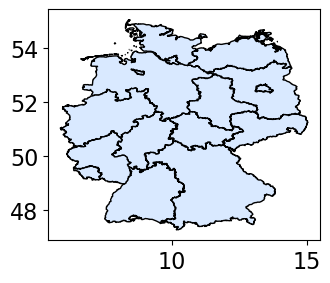

In [2]:
# Path to cache folder
data_cache_folder = pathlib.Path().cwd().parent.parent.joinpath("geokit", "data")

# Path to shapefile folder
path_to_shape_file = get_test_data(
    file_name="gadm36_DEU_1.shp",
    data_cache_folder=data_cache_folder,
)

# Load vector dataset from a Shapefile and reproject to EPSG:4326
world = geokit.core.vector.extractFeatures(path_to_shape_file, srs=4326)

# Visualize vector dataset
ax = gk.drawGeoms(world, srs=4326, figsize=(4, 3))

## Plot multiple vector files and overlay them with other vector files


GeoKit provides the ability plot multiple vector files next or/and on top of each other. Visualizing multiple vector datasets together allows comparing and highliting spatial features and understanding their geographic relationships. This example shows how to plot several vector files in a single figure and overlay them on the same map.


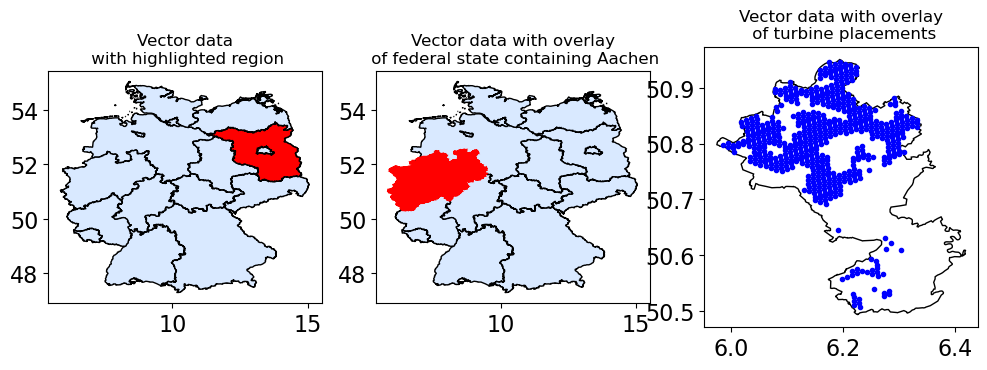

In [3]:
import matplotlib.pyplot as plt

# Create two subplots for side-by-side comparison
fig, ax = plt.subplots(ncols=3, figsize=(12, 5))

# ---------------------------------------------
# ---- Left plot: base dataset + highlight one subregion ----
# ---------------------------------------------
# Data Federal States of Germany
path_to_shape_file = get_test_data(
    file_name="gadm36_DEU_1.shp",
    data_cache_folder=data_cache_folder,
)
world = geokit.core.vector.extractFeatures(path_to_shape_file, srs=4326)
gk.drawGeoms(world, srs=4326, ax=ax[0])

g2 = world.geom.iloc[3]
geokit.core.geom.drawGeoms(g2, ax=ax[0], fc="red")

ax[0].autoscale()
ax[0].set_title("Vector data\n with highlighted region")

# ---------------------------------------------
# ---- Mid plot: base dataset + overlay geometry ----
# ---------------------------------------------
# Point of Aachen
aachen_pt_real = geokit.core.geom.point((6.083, 50.775), srs=geokit.core.srs.EPSG4326)
path_to_shape_file = get_test_data(
    file_name="gadm36_DEU_1.shp",
    data_cache_folder=data_cache_folder,
)
# Filter for the federal state containing Aachen
federal_states_DE_df_geom_filtered = geokit.core.vector.extractFeatures(path_to_shape_file, geom=aachen_pt_real)

# Draw base dataset
gk.drawGeoms(world, srs=4326, ax=ax[1])
# Draw overlay federal state of Aachen geometry
gk.drawGeoms(federal_states_DE_df_geom_filtered, ax=ax[1], srs=4326, fc="red", ec="red", lw=2)

ax[1].autoscale()
ax[1].set_title("Vector data with overlay\n of federal state containing Aachen")

# ---------------------------------------------
# ---- Right plot: Aachen + overlay ----
# ---------------------------------------------
# Draw overlay Aachen geometry
path_to_aachen_shape_file = get_test_data(
    file_name="aachenShapefile.shp",
    data_cache_folder=data_cache_folder,
)
aachen_rm = geokit.core.vector.extractFeatures(path_to_aachen_shape_file)
geokit.core.geom.drawGeoms(aachen_rm, ax=ax[2], srs=4326, fc="None")

# Plot Turbine Placements
path_to_turbine_placement_file = get_test_data(
    file_name="turbinePlacements.shp",
    data_cache_folder=data_cache_folder,
)
turbine_placements = geokit.core.vector.extractFeatures(path_to_turbine_placement_file)
geokit.core.geom.drawGeoms(turbine_placements, ax=ax[2], srs=4326, color="blue", markersize=3)
ax[2].set_title("Vector data with overlay\n of turbine placements")
ax[2].autoscale()